In [1]:
import warnings
warnings.filterwarnings('ignore')

In [2]:
from google.colab import files
uploaded = files.upload()

Saving wdbc.data to wdbc.data


In [2]:
import pandas as pd

column_names = [
    "ID", "Diagnosis", "Radius_mean", "Texture_mean", "Perimeter_mean", "Area_mean",
    "Smoothness_mean", "Compactness_mean", "Concavity_mean", "Concave_points_mean",
    "Symmetry_mean", "Fractal_dimension_mean", "Radius_se", "Texture_se", "Perimeter_se",
    "Area_se", "Smoothness_se", "Compactness_se", "Concavity_se", "Concave_points_se",
    "Symmetry_se", "Fractal_dimension_se", "Radius_worst", "Texture_worst", "Perimeter_worst",
    "Area_worst", "Smoothness_worst", "Compactness_worst", "Concavity_worst",
    "Concave_points_worst", "Symmetry_worst", "Fractal_dimension_worst"
]

# Load the dataset
df = pd.read_csv("wdbc.data", header=None, names=column_names)

# Save to CSV with column names
df.to_csv("breast_cancer_diagnostic.csv", index=False)

# Display the first few rows
print(df.head())

         ID Diagnosis  Radius_mean  Texture_mean  Perimeter_mean  Area_mean  \
0    842302         M        17.99         10.38          122.80     1001.0   
1    842517         M        20.57         17.77          132.90     1326.0   
2  84300903         M        19.69         21.25          130.00     1203.0   
3  84348301         M        11.42         20.38           77.58      386.1   
4  84358402         M        20.29         14.34          135.10     1297.0   

   Smoothness_mean  Compactness_mean  Concavity_mean  Concave_points_mean  \
0          0.11840           0.27760          0.3001              0.14710   
1          0.08474           0.07864          0.0869              0.07017   
2          0.10960           0.15990          0.1974              0.12790   
3          0.14250           0.28390          0.2414              0.10520   
4          0.10030           0.13280          0.1980              0.10430   

   ...  Radius_worst  Texture_worst  Perimeter_worst  Area_wor

In [ ]:
# XGBoost

# XGBoost

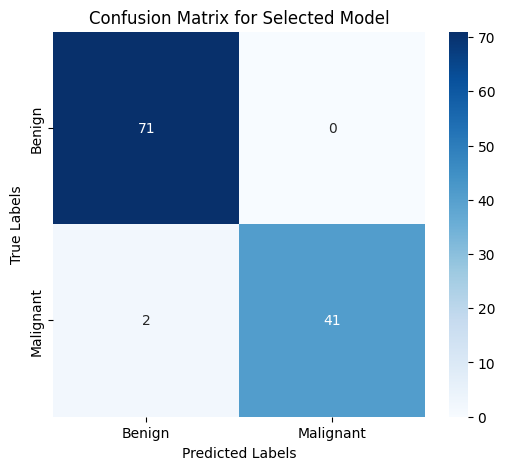

XGBoost Model Results:
Accuracy: 0.9825
Precision: 1.0000
Recall: 0.9535
F1-score: 0.9762
MCC: 0.9630
ROC AUC: 0.9974


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier, GradientBoostingClassifier, BaggingClassifier
from xgboost import XGBClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, matthews_corrcoef, roc_auc_score, roc_curve, auc,
                             confusion_matrix)


selected_features = ['Perimeter_mean', 'Smoothness_mean', 'Compactness_mean', 'Texture_worst', 'Perimeter_worst']
X = df[selected_features]
Y = df.iloc[:, 1]

if Y.dtype == 'object':
    Y = Y.map({'B': 0, 'M': 1})

X_train, X_test, y_train, y_test = train_test_split(X, Y, test_size=0.2, random_state=42)

# Scaling
sc = StandardScaler()
X_train_scaled = sc.fit_transform(X_train)
X_test_scaled = sc.transform(X_test)

# Train XGBoost model
xgb_model = XGBClassifier(use_label_encoder=False, eval_metric='logloss')
xgb_model.fit(X_train_scaled, y_train)

# Predictions
y_pred = xgb_model.predict(X_test_scaled)
y_pred_proba = xgb_model.predict_proba(X_test_scaled)[:, 1]  # For ROC AUC

# Compute confusion matrix
conf_matrix = confusion_matrix(y_test, y_pred)

# Plot confusion matrix
plt.figure(figsize=(6, 5))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=['Benign', 'Malignant'], yticklabels=['Benign', 'Malignant'])
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.title('Confusion Matrix for Selected Model')
plt.show()

# Compute metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
mcc = matthews_corrcoef(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_pred_proba)

# Print results
print("XGBoost Model Results:")
print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1-score: {f1:.4f}")
print(f"MCC: {mcc:.4f}")
print(f"ROC AUC: {roc_auc:.4f}")

# Save the model

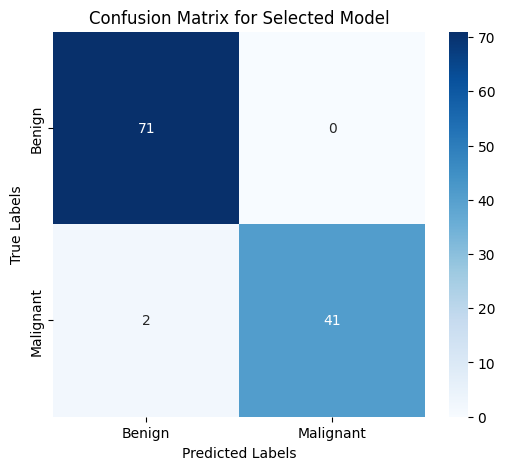

XGBoost Model Results:
Accuracy: 0.9825
Precision: 1.0000
Recall: 0.9535
F1-score: 0.9762
MCC: 0.9630
ROC AUC: 0.9974


In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier, GradientBoostingClassifier, BaggingClassifier
from xgboost import XGBClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, matthews_corrcoef, roc_auc_score, roc_curve, auc,
                             confusion_matrix)

# Define selected features
selected_features = ['Perimeter_mean', 'Smoothness_mean', 'Compactness_mean', 'Texture_worst', 'Perimeter_worst']
X = df[selected_features]
Y = df.iloc[:, 1]

if Y.dtype == 'object':
    Y = Y.map({'B': 0, 'M': 1})

X_train, X_test, y_train, y_test = train_test_split(X, Y, test_size=0.2, random_state=42)

# Scaling
sc = StandardScaler()
X_train_scaled = sc.fit_transform(X_train)
X_test_scaled = sc.transform(X_test)

# Train XGBoost model
xgb_model = XGBClassifier(use_label_encoder=False, eval_metric='logloss')
xgb_model.fit(X_train_scaled, y_train)

# Save model using pickle
with open('xgb_model.pkl', 'wb') as model_file:
    pickle.dump(xgb_model, model_file)

# Save scaler using pickle
with open('xgb_scaler.pkl', 'wb') as scaler_file:
    pickle.dump(sc, scaler_file)

# Predictions
y_pred = xgb_model.predict(X_test_scaled)
y_pred_proba = xgb_model.predict_proba(X_test_scaled)[:, 1]  # For ROC AUC

# Compute confusion matrix
conf_matrix = confusion_matrix(y_test, y_pred)

# Plot confusion matrix
plt.figure(figsize=(6, 5))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=['Benign', 'Malignant'], yticklabels=['Benign', 'Malignant'])
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.title('Confusion Matrix for Selected Model')
plt.show()

# Compute metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
mcc = matthews_corrcoef(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_pred_proba)

# Print results
print("XGBoost Model Results:")
print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1-score: {f1:.4f}")
print(f"MCC: {mcc:.4f}")
print(f"ROC AUC: {roc_auc:.4f}")
